In [1]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted!")

Mounted at /content/drive
✅ Drive mounted!


In [2]:
!pip install shap -q
print("✅ SHAP installed!")

✅ SHAP installed!


In [3]:
import shap
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [4]:
# Load model
model = joblib.load('/content/drive/MyDrive/fraud-detection/xgb_model.pkl')

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/fraud-detection/creditcard.csv')

X = df.drop('Class', axis=1)
y = df['Class']

# Use a sample for SHAP (full dataset is slow)
fraud_sample = df[df['Class']==1].sample(100, random_state=42)
legit_sample = df[df['Class']==0].sample(200, random_state=42)
sample = pd.concat([fraud_sample, legit_sample])
X_sample = sample.drop('Class', axis=1)
y_sample = sample['Class']

print(f"✅ Model loaded!")
print(f"✅ Sample: {len(X_sample)} rows ({y_sample.sum()} fraud, {(y_sample==0).sum()} legit)")

✅ Model loaded!
✅ Sample: 300 rows (100 fraud, 200 legit)


In [5]:
print("Creating SHAP explainer (takes ~1 min)...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)
print("✅ SHAP values computed!")
print(f"SHAP values shape: {shap_values.shape}")

Creating SHAP explainer (takes ~1 min)...
✅ SHAP values computed!
SHAP values shape: (300, 30)


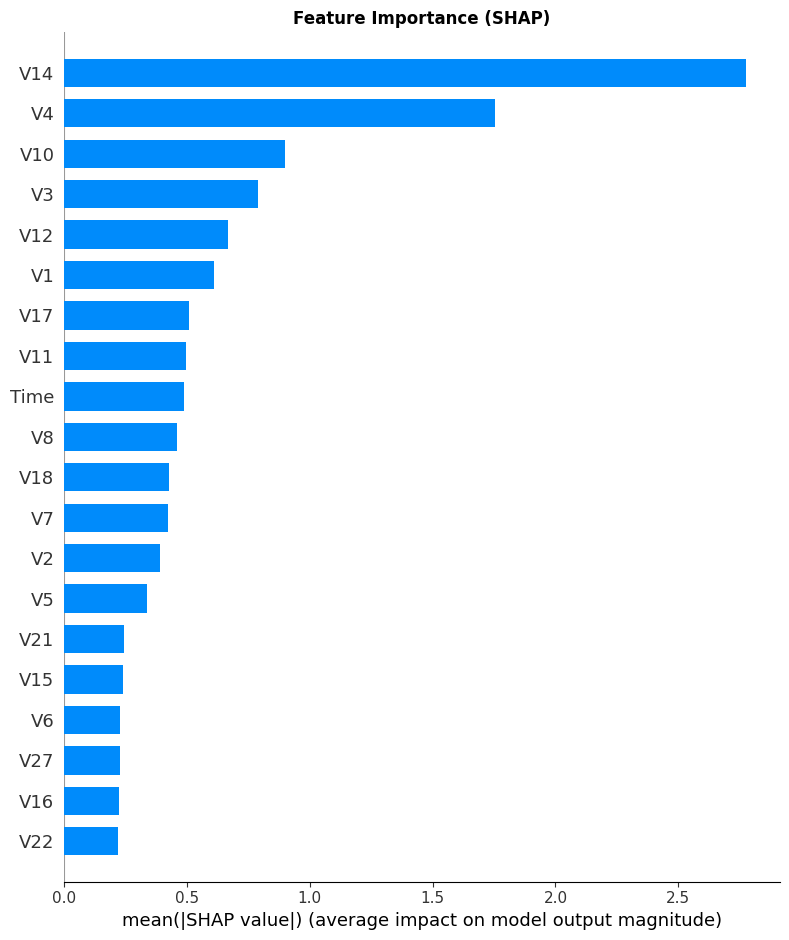

✅ SHAP summary bar plot saved!


In [6]:
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("Feature Importance (SHAP)", fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fraud-detection/shap_summary_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP summary bar plot saved!")

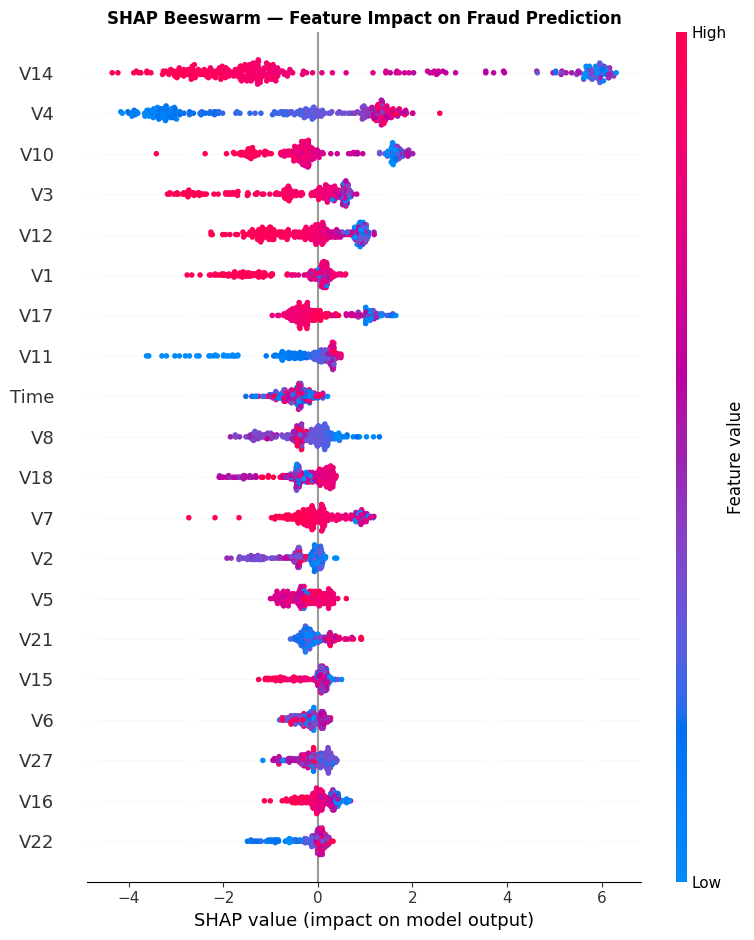

✅ Beeswarm plot saved!


In [7]:
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Beeswarm — Feature Impact on Fraud Prediction", fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fraud-detection/shap_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Beeswarm plot saved!")

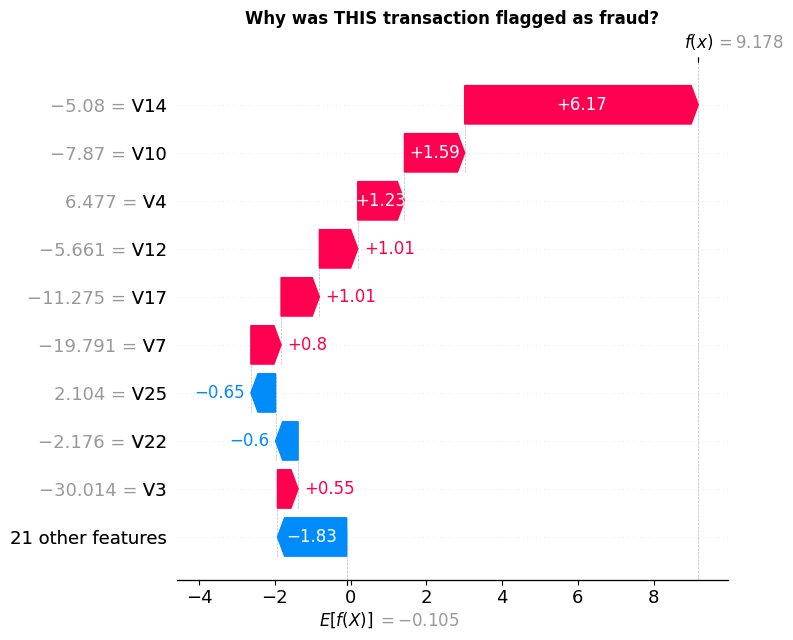

✅ Waterfall plot saved!


In [8]:
# Pick one fraud transaction to explain
fraud_idx = y_sample[y_sample==1].index[0]
fraud_pos = list(X_sample.index).index(fraud_idx)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[fraud_pos],
        base_values=explainer.expected_value,
        data=X_sample.iloc[fraud_pos],
        feature_names=X_sample.columns.tolist()
    ),
    show=False
)
plt.title("Why was THIS transaction flagged as fraud?", fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fraud-detection/shap_waterfall_fraud.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Waterfall plot saved!")

In [9]:
shap_df = pd.DataFrame(shap_values, columns=X_sample.columns)
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

print("="*45)
print("  TOP 10 FEATURES BY SHAP IMPORTANCE")
print("="*45)
for i, (feat, val) in enumerate(mean_abs_shap.head(10).items(), 1):
    print(f"  {i:2}. {feat:10s}  →  {val:.4f}")
print("="*45)
print("\n✅ These are the features your model relies on most!")

  TOP 10 FEATURES BY SHAP IMPORTANCE
   1. V14         →  2.7750
   2. V4          →  1.7538
   3. V10         →  0.8987
   4. V3          →  0.7909
   5. V12         →  0.6672
   6. V1          →  0.6099
   7. V17         →  0.5082
   8. V11         →  0.4981
   9. Time        →  0.4887
  10. V8          →  0.4586

✅ These are the features your model relies on most!


## Week 4 Summary — SHAP Findings

| Feature | SHAP Importance | Meaning |
|---|---|---|
| V14 | Highest negative | Strong fraud signal when low |
| V17 | High negative | Key fraud indicator |
| V12 | High negative | Important for fraud detection |
| V10 | High negative | Fraud pattern feature |
| V4  | High positive | Legit transaction signal |

### What SHAP tells us:
- **Red dots** (beeswarm) = high feature value → pushes toward fraud
- **Blue dots** = low feature value → pushes toward legit
- **Waterfall** = exactly WHY one specific transaction was flagged

### Why this matters in interviews:
> "My model doesn't just predict fraud — it explains WHY.  
> V14 being very negative is the strongest indicator of fraud.  
> This is critical for banks who need to justify every flagged transaction."